# CDS quickstart — downloading ERA5 via the `Earthly` facade

End-to-end example of pulling a small ERA5 retrieval from the
Copernicus Climate Data Store using `earthly`. The factory-style
`Earthly` facade keeps the backend choice behind one string key, so
the same call shape works for CHIRPS / S3 / GEE — only `data_source`
changes.

**What this notebook covers**

1. Verifying CDS credentials.
2. Browsing the variable catalog.
3. Submitting a retrieve through the facade.
4. Inspecting the NetCDF that lands on disk.
5. Bundling per-window aggregation into the same `download()` call.
6. Plotting one of the resulting GeoTIFFs.

**Heads-up.** The retrieve in **Step 4** blocks on the CDS queue —
typically 1–10 minutes for a small request. The bbox / date range used
below is intentionally tiny so the demo finishes fast.

## Prerequisites

Three things need to be in place before any CDS retrieve will work:

1. **A CDS account** — register at https://cds.climate.copernicus.eu.
2. **A Personal Access Token** in `~/.cdsapirc` (Linux/macOS) or
   `C:\Users\<USER>\.cdsapirc` (Windows). Format:
   ```
   url: https://cds.climate.copernicus.eu/api
   key: <YOUR-TOKEN>
   ```
3. **The dataset's licence accepted** on its CDS page. Open
   https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels
   and tick the licence at the bottom of the *Download* tab.

The package itself is installed via `pip install earthly[ecmwf]` (the
`ecmwf` extra pulls in `cdsapi`).

## Step 1 — verify credentials

If `~/.cdsapirc` is missing, every retrieve raises
`AuthenticationError` with a message pointing at the file location.

In [1]:
from pathlib import Path

rc = Path.home() / ".cdsapirc"
print(f"~/.cdsapirc found: {rc.is_file()} ({rc})")

~/.cdsapirc found: True (C:\Users\main\.cdsapirc)


## Step 2 — browse the catalog

`Catalog` loads `cds_data_catalog.yaml` (shipped as package data) and
exposes every CDS dataset earthly knows about, with the per-variable
metadata each retrieve needs. Lookups are by `(dataset_name, variable_code)`
since the same short code can appear under more than one dataset.

In [2]:
from earthly.ecmwf import Catalog

cat = Catalog()
print(f"{len(cat.available_datasets)} CDS datasets in catalog")

spec = cat.get_variable(
    "reanalysis-era5-single-levels", "2m-temperature"
)
print(f"cds_variable: {spec.cds_variable}")
print(f"nc_variable:  {spec.nc_variable}")
print(f"units:        {spec.units}")
print(f"is_flux:      {spec.is_flux}  # state -> auto resolves to mean")

134 CDS datasets in catalog
cds_variable: 2m_temperature
nc_variable:  t2m
units:        K
is_flux:      False  # state -> auto resolves to mean


## Step 3 — pick a small region and date range

Three days of 2-metre temperature over a ~1° box around Coello,
Colombia. Small enough that the CDS queue normally serves it in a
few minutes; the resulting NetCDF is ~10 KB.

In [3]:
OUT = Path("data/era5")
OUT.mkdir(parents=True, exist_ok=True)

request = dict(
    start="2022-01-01",
    end="2022-01-03",
    temporal_resolution="daily",
    variables={
        "reanalysis-era5-single-levels": ["2m-temperature"],
    },
    lat_lim=[4.0, 5.0],
    lon_lim=[-75.0, -74.0],
    path=str(OUT),
)
request

{'start': '2022-01-01',
 'end': '2022-01-03',
 'temporal_resolution': 'daily',
 'variables': {'reanalysis-era5-single-levels': ['2m-temperature']},
 'lat_lim': [4.0, 5.0],
 'lon_lim': [-75.0, -74.0],
 'path': 'data\\era5'}

## Step 4 — submit the retrieve via the `Earthly` facade

`Earthly(data_source="ecmwf", ...)` resolves to the `ECMWF` backend
behind the scenes; switching to a different provider is a one-string
change. The `download()` call assembles the cdsapi request, runs the
pre-flight `RequestValidator`, and submits to CDS. It blocks on the
queue until the NetCDF is written.

In [4]:
from earthly import Earthly

earthly = Earthly(data_source="ecmwf", **request)
earthly.download()  # blocks during CDS queue + retrieve (~1–10 min)

2026-05-10 01:33:33.728 | INFO     | earthly.ecmwf.backend:download:536 - Download ECMWF reanalysis-era5-single-levels/2m-temperature data for period 2022-01-01 00:00:00 till 2022-01-03 00:00:00


2026-05-10 01:33:34.789 | INFO     | earthly.ecmwf.backend:_api:724 - Requesting reanalysis-era5-single-levels from CDS; this may take several minutes


2026-05-10 01:33:35,110 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)


2026-05-10 01:33:35,111 INFO Request ID is ed913c29-3ab4-4e36-bf6b-719d2a2e0dcc


2026-05-10 01:33:35,194 INFO status has been updated to accepted


2026-05-10 01:33:56,672 INFO status has been updated to running


2026-05-10 01:34:08,139 INFO status has been updated to successful


5c0c1268f32613f0fe8b1ca870564045.nc:   0%|          | 0.00/24.7k [00:00<?, ?B/s]

2026-05-10 01:34:09.169 | INFO     | earthly.ecmwf.backend:download:575 - ECMWF download summary: all 1 variables succeeded ([('reanalysis-era5-single-levels', '2m-temperature')])


## Step 5 — verify the NetCDF

Per-variable NetCDFs land at `<path>/<cds_variable>_<cds_dataset>.nc`.
Open one with `pyramids.netcdf.NetCDF` and inspect the dimensions and
value range.

In [5]:
from pyramids.netcdf import NetCDF
import numpy as np

nc_path = OUT / "2m_temperature_reanalysis-era5-single-levels.nc"
nc = NetCDF.read_file(str(nc_path))
print(f"dimensions: {nc.dimension_names}")

arr = nc.read_array(variable=spec.nc_variable)
print(f"shape:      {arr.shape}  # (time-slots, lat, lon)")
print(f"range:      {np.nanmin(arr):.2f} .. {np.nanmax(arr):.2f} K")
print(f"mean:       {np.nanmean(arr):.2f} K")

2026-05-10 01:34:09 | INFO | pyramids.base.config | Logging is configured.


dimensions: ['valid_time', 'latitude', 'longitude']
shape:      (12, 5, 5)  # (time-slots, lat, lon)
range:      279.30 .. 306.52 K
mean:       292.47 K


## Step 6 — bundle download + aggregation

Daily ERA5 NetCDFs carry four 6-hourly slots per day. To get one
GeoTIFF *per day* with the right reduction (mean for state variables
like temperature, sum for fluxes like evaporation), pass an
`AggregationConfig` to `download()`. The backend retrieves the NetCDF
and immediately runs `aggregate_netcdf` against it.

`op="auto"` reads `Variable.is_flux` from the catalog — temperature
is a state variable, so `auto` resolves to `mean`.

In [6]:
from earthly import AggregationConfig

OUT2 = Path("data/era5-aggregated")
OUT2.mkdir(parents=True, exist_ok=True)

earthly = Earthly(data_source="ecmwf", **{**request, "path": str(OUT2)})
earthly.download(
    aggregate=AggregationConfig(freq="1D", op="auto"),
)

2026-05-10 01:34:10.366 | INFO     | earthly.ecmwf.backend:download:536 - Download ECMWF reanalysis-era5-single-levels/2m-temperature data for period 2022-01-01 00:00:00 till 2022-01-03 00:00:00


2026-05-10 01:34:10.372 | INFO     | earthly.ecmwf.backend:_api:724 - Requesting reanalysis-era5-single-levels from CDS; this may take several minutes


2026-05-10 01:34:11,198 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)


2026-05-10 01:34:11 | INFO | ecmwf.datastores.legacy_client | [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)


2026-05-10 01:34:11,199 INFO Request ID is a68cd9f7-59c8-4cbc-a092-c66e17757c38


...

2026-05-10 01:34:44,192 INFO status has been updated to successful


2026-05-10 01:34:44 | INFO | ecmwf.datastores.legacy_client | status has been updated to successful


2026-05-10 01:34:44 | INFO | multiurl.base | Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-05-09/5c0c1268f32613f0fe8b1ca870564045.nc


5c0c1268f32613f0fe8b1ca870564045.nc:   0%|          | 0.00/24.7k [00:00<?, ?B/s]

2026-05-10 01:34:45.099 | INFO     | earthly.ecmwf.backend:download:575 - ECMWF download summary: all 1 variables succeeded ([('reanalysis-era5-single-levels', '2m-temperature')])


## Step 7 — list the per-window GeoTIFFs

When `aggregate.out_dir` is left at its `None` default, the backend
lands the GeoTIFFs at `<path>/aggregated/`. Each filename follows
`<cds_variable>_<freq>_<window>.tif`.

In [7]:
tifs = sorted((OUT2 / "aggregated").glob("*.tif"))
for t in tifs:
    print(t.name)

2m_temperature_1D_20220101.tif
2m_temperature_1D_20220102.tif
2m_temperature_1D_20220103.tif


## Step 8 — plot one of the daily-mean rasters

Quick visual check that the aggregation produced a sensible 2-D array.

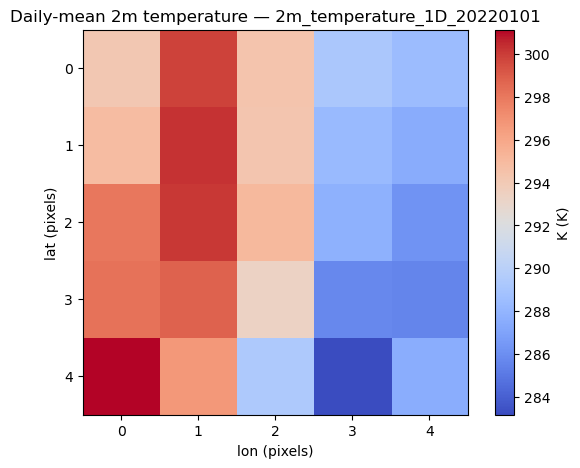

In [8]:
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset

ds = Dataset.read_file(str(tifs[0]))
img = ds.read_array()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(img, cmap="coolwarm")
ax.set_title(f"Daily-mean 2m temperature — {tifs[0].stem}")
ax.set_xlabel("lon (pixels)")
ax.set_ylabel("lat (pixels)")
fig.colorbar(im, ax=ax, label=f"K ({spec.units})")
plt.show()

## Where to go from here

- **More variables / longer ranges** — add entries to the `variables`
  dict and widen `start` / `end`. Each retrieve still produces one
  NetCDF per `(dataset, variable)` pair.
- **Monthly means** — name the monthly dataset directly in `variables`,
  e.g. `"reanalysis-era5-single-levels-monthly-means"`. The catalog
  auto-synthesizes that entry; the loader picks `product_type=
  ["monthly_averaged_reanalysis"]` for you.
- **Pressure-level data** — use
  `"reanalysis-era5-pressure-levels"` and pass
  `level=1000` (or whatever pressure) on `AggregationConfig` so the
  reducer runs on a 3-D slice.
- **Other reductions** — pass `op="sum"` / `"min"` / `"max"` / `"std"`
  explicitly to bypass the catalog-driven `auto` routing.
- **Standalone aggregation** — call `aggregate_netcdf(nc_path,
  var_info, config)` directly against any pyramids-readable NetCDF;
  no `Earthly` instance needed.

Full reference for the aggregation feature lives under the
**Data Sources → ECMWF → Aggregation** tab in the docs.